![](https://images.pexels.com/photos/1331750/pexels-photo-1331750.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1)

In basketball, players are assigned specific positions on the court based on their skills, physical attributes, and playing style. The positions are traditionally divided into five main roles, each with its own responsibilities. While players may have some flexibility within these positions, understanding these roles helps teams organize their strategies and tactics. Here are the typical basketball positions:

**Point Guard (PG)**:

The point guard is often considered the team's floor general. They are responsible for bringing the ball up the court, setting up plays, and distributing the ball to their teammates. Point guards are usually excellent ball handlers and playmakers. They need to be quick, agile, and have good decision-making skills.

**Shooting Guard (SG)**:

The shooting guard is often one of the team's primary scorers. They are expected to be strong shooters from mid-range and beyond the three-point line. Shooting guards should also be capable of driving to the basket and creating scoring opportunities. Defensively, they may be tasked with guarding the opponent's best perimeter scorer.

**Small Forward (SF)**:

The small forward is a versatile player who needs to contribute both offensively and defensively. Small forwards are typically strong all-around players, capable of scoring from the perimeter, driving to the basket, and playing solid defense. They often have a mix of size, athleticism, and skill.

**Power Forward (PF)**:

Power forwards are usually strong and physical players who operate in the post area near the basket. They are expected to score inside, grab rebounds, and play tough defense. In modern basketball, power forwards are also required to have some shooting range and the ability to stretch the floor. They often play a key role in both offense and defense.

**Center (C)**:

The center is typically the tallest player on the team and plays near the basket on both ends of the court. Their primary responsibilities include rebounding, shot-blocking, scoring in the paint, and defending against opponents' shots. Centers are essential for protecting the rim and controlling the boards. In some cases, centers may also have the ability to score from mid-range or beyond.

Basketball strategies and playing styles can evolve, and players may exhibit skills that transcend traditional position definitions. This has led to the rise of more versatile players who can play multiple positions, contributing to the ongoing evolution of the game. The specific roles and player attributes can vary depending on the team's philosophy and the coaching staff's preferences.

Using the anthropometric data from NBA Draft Combine I will create a **Random Forest model** that is able to predict the **position of a player** based on the **anthropometric measurements** (height, weight, etc.).

# 📥 Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 📄 Loading the data

In [2]:
df = pd.read_csv("/kaggle/input/nba-anthropometric/NBA_Anthropometric.csv")
df.head()

,player_name,position,height,height_with_shoes,weight,wingspan,standing_reach,body_fat_percentage,hand_length,hand_width,draft_year
0,Trey Alexander,SG,191.14,NaN,83.73,208.28,257.81,NaN,21.59,22.22,2023
1,Amari Bailey,SG,191.14,NaN,86.55,200.66,262.89,NaN,20.32,23.50,2023
2,Emoni Bates,SF,203.84,NaN,81.28,205.74,266.70,NaN,20.32,20.96,2023
3,Reece Beekman,PG,186.69,NaN,86.45,200.66,255.27,NaN,21.59,20.96,2023
4,Anthony Black,PG,197.48,NaN,95.25,201.93,260.35,NaN,20.96,24.13,2023


# 🔎 Exploratory Data Analysis

In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1633 entries, 0 to 1632
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_name          1633 non-null   object 
 1   position             1628 non-null   object 
 2   height               1575 non-null   float64
 3   height_with_shoes    1205 non-null   float64
 4   weight               1573 non-null   float64
 5   wingspan             1575 non-null   float64
 6   standing_reach       1574 non-null   float64
 7   body_fat_percentage  1276 non-null   float64
 8   hand_length          839 non-null    float64
 9   hand_width           839 non-null    float64
 10  draft_year           1633 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 140.5+ KB


,count,mean,std,min,25%,50%,75%,max
height,1575.0,197.105251,8.525178,172.08,191.1400,197.48,203.52,226.70
height_with_shoes,1205.0,200.123859,8.386410,175.26,194.3100,200.66,206.38,231.14
weight,1573.0,97.699943,11.918915,67.68,88.9000,96.89,105.78,151.50
wingspan,1575.0,209.302070,10.177711,177.80,202.5600,209.55,216.54,249.56
standing_reach,1574.0,262.912846,12.391138,224.79,254.0000,264.16,271.78,311.15
body_fat_percentage,1276.0,7.529169,2.933166,2.60,5.4375,6.70,8.80,23.10
hand_length,839.0,22.138892,1.195369,19.05,21.5900,22.22,22.86,26.67
hand_width,839.0,23.915161,1.797656,17.78,22.8600,24.13,25.40,30.48
draft_year,1633.0,2011.251072,7.201710,2000.00,2005.0000,2011.00,2018.00,2023.00


Checking the correlation of features

<Axes: >

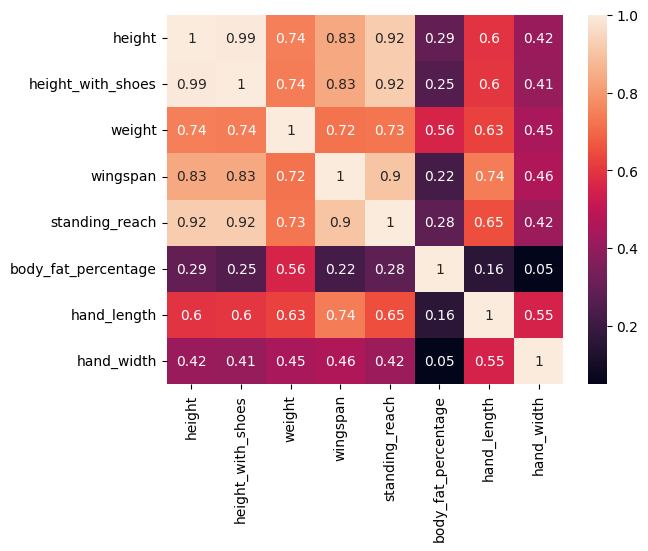

In [4]:
sb.heatmap(df.drop(columns=['position', 'player_name', 'draft_year']).corr(), cmap='rocket', annot=True)

Checking the amount of missing values

player_name              0
position                 5
height                  58
height_with_shoes      428
weight                  60
wingspan                58
standing_reach          59
body_fat_percentage    357
hand_length            794
hand_width             794
draft_year               0
dtype: int64


<Axes: >

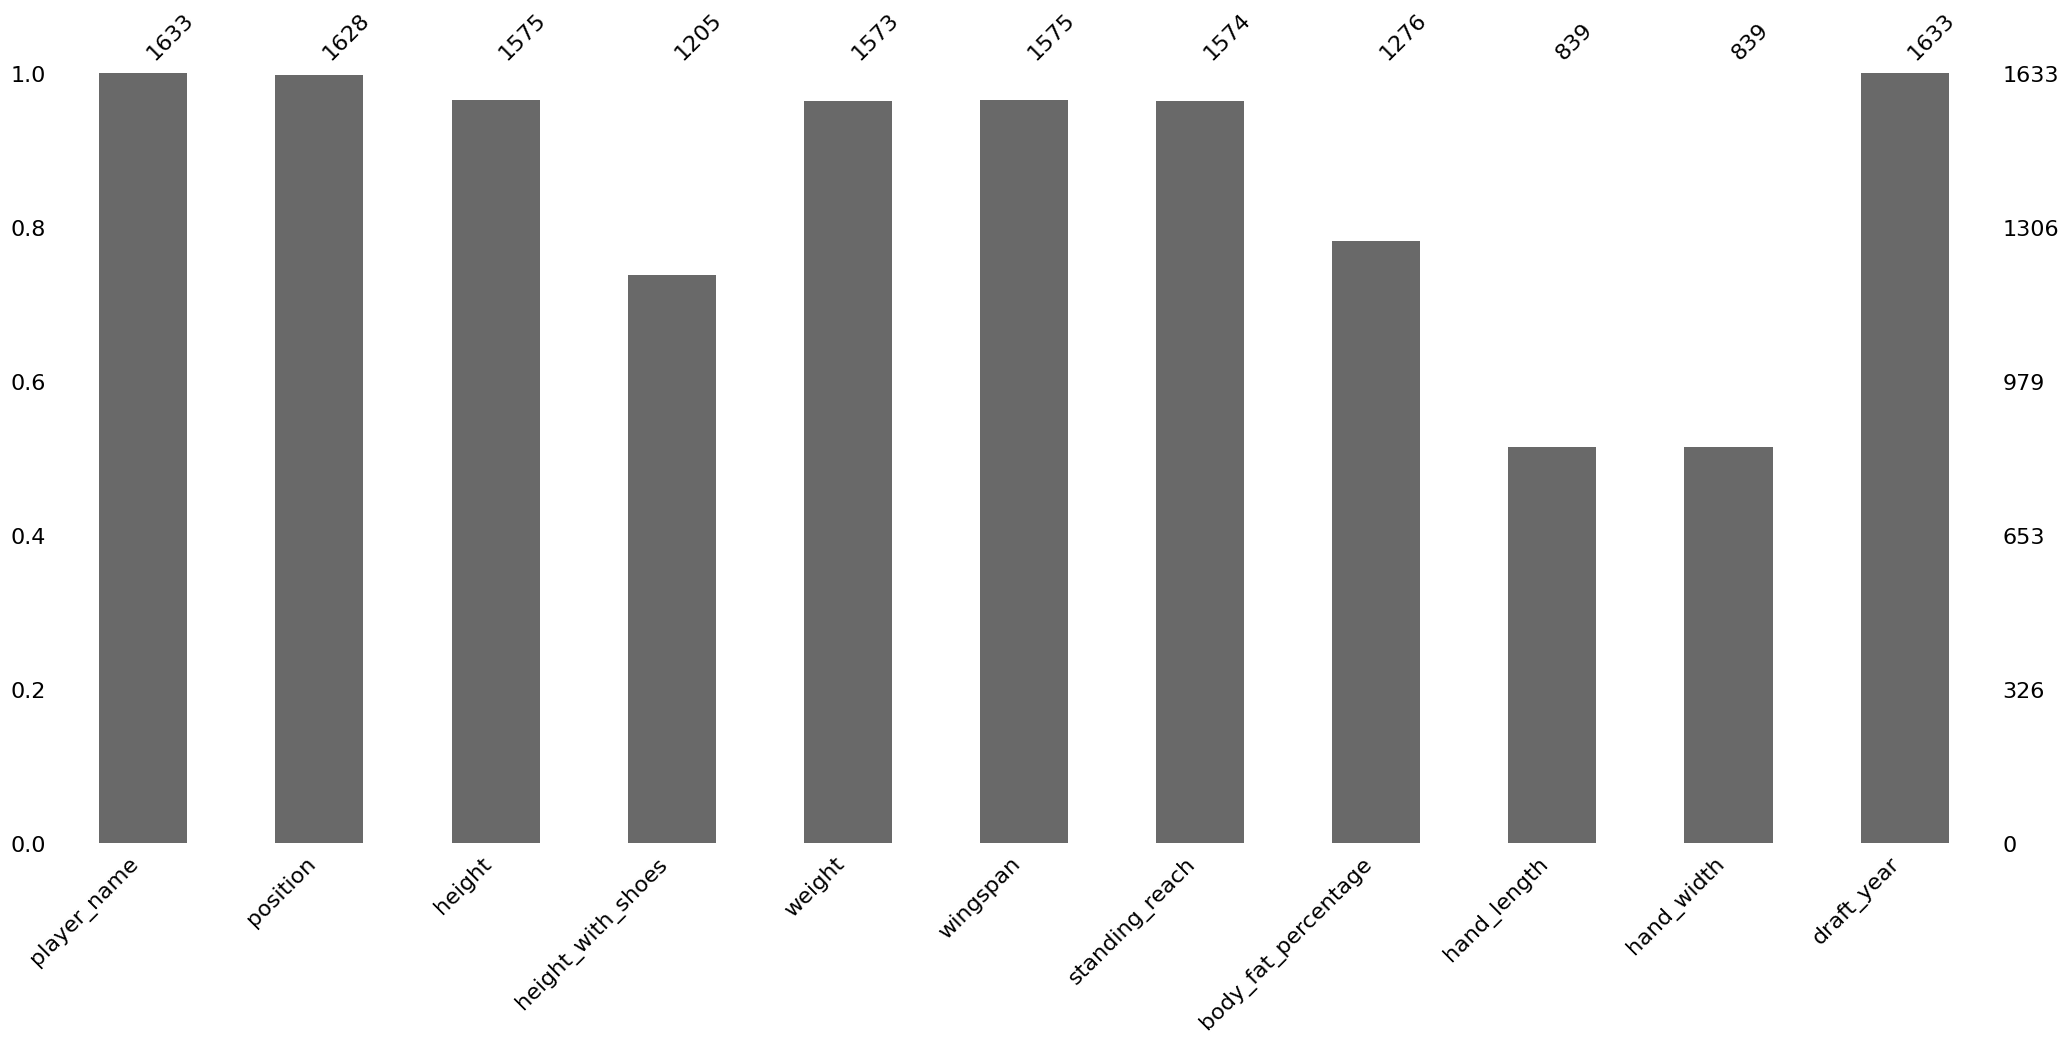

In [5]:
print(df.isna().sum())
msno.bar(df)

height                -0.228998
height_with_shoes     -0.194768
weight                 0.431045
wingspan              -0.224525
standing_reach        -0.220017
body_fat_percentage    1.374119
hand_length            0.156273
hand_width             0.116728
dtype: float64


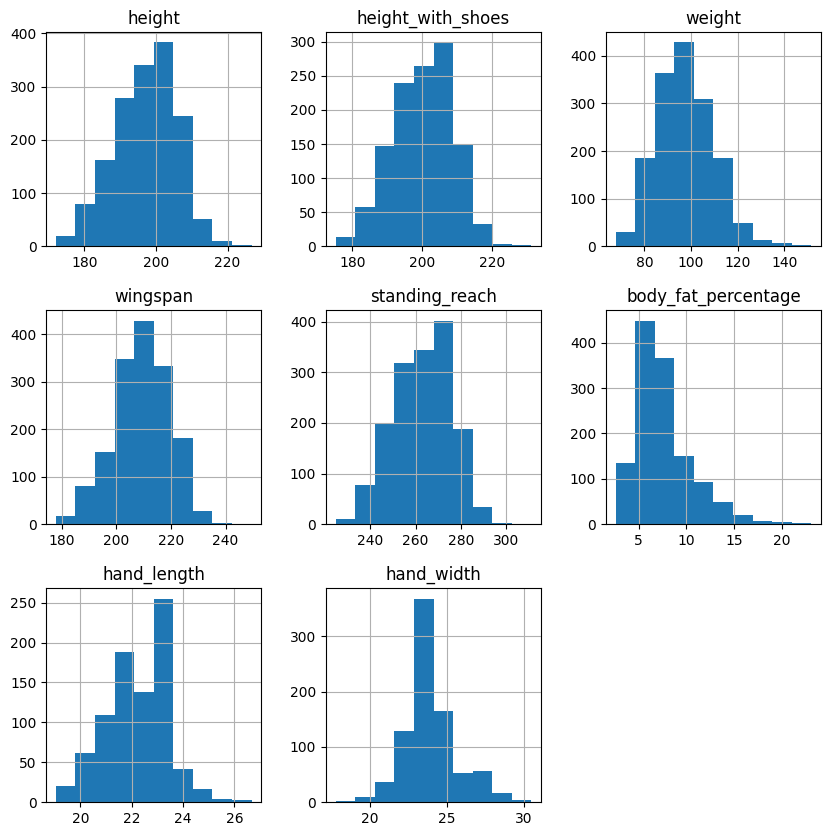

In [6]:
df.drop(columns=['position', 'player_name', 'draft_year']).hist(figsize=(10,10));
print(df.drop(columns=['position', 'player_name', 'draft_year']).skew())

Dropping duplicated names and keeping only the latest entry (due to same players attending the draft combine in multiple years)

In [7]:
df = df.sort_values("draft_year", ascending=False).drop_duplicates(["player_name"], keep='first')

Keeping only the primary position where there are two positions (eg. "PG/SG")

In [8]:
def extract_primary_position(x):
    if type(x)==float:
        return x
    elif "/" in x:
        return x.split("/")[0]
    else:
        return x

df["position"] = df["position"].apply(extract_primary_position)
df["position"].unique()

array(['SG', 'PF', 'SF', 'PG', 'C', nan], dtype=object)

Dropping unnecessary columns and NaN values

In [9]:
df = df.drop(columns=["height_with_shoes", "draft_year", "player_name"])
df = df.dropna(subset=["position", "height", "weight", "wingspan", "standing_reach"])

# 📑 Splitting the dataset into train and test subsets

In [10]:
X = df.drop(columns='position')
Y = df['position']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state = 42)

# 📝 Median Imputation

In [11]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# 📐 Feature Scaling

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🌲 Random Forest Modelling


Accuracy: 69.71%

              precision    recall  f1-score   support

           C       0.55      0.48      0.51        25
          PF       0.67      0.72      0.69        83
          PG       0.86      0.81      0.83        53
          SF       0.62      0.56      0.59        68
          SG       0.73      0.78      0.75        78

    accuracy                           0.70       307
   macro avg       0.68      0.67      0.68       307
weighted avg       0.70      0.70      0.70       307



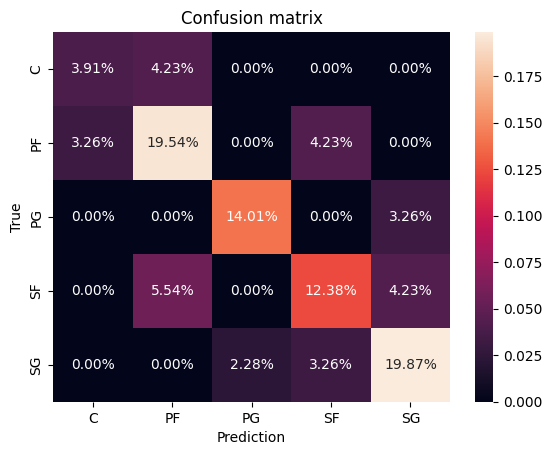

In [13]:
model = RandomForestClassifier(random_state=50)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
acc = (accuracy_score(Y_test,Y_pred)*100).round(2)
print(f'\nAccuracy: {acc}%\n')
print(classification_report(Y_test,Y_pred))
cm = confusion_matrix(Y_test,Y_pred)

mt_labels = pd.DataFrame(classification_report(Y_test,Y_pred, output_dict=True).keys())
mt_labels = list(mt_labels.loc[~mt_labels[0].isin(["accuracy","macro avg", "weighted avg"])][0])

sb.heatmap(cm/cm.sum(), annot= True, fmt= '0.2%', cmap= 'rocket',xticklabels=mt_labels, yticklabels=mt_labels)
plt.xlabel("Prediction")
plt.ylabel("True")
plt.title("Confusion matrix")
plt.show()

In [14]:
print(f"The model has achieved {acc}% accuracy")

The model has achieved 69.71% accuracy
